# Multiple Items and Constraints

Often businesses sell more than one product, and have have real world considerations like a stock budget, storage limitations, manufacturing time, or even weight for transportation costs. This notebook serves as an introduction into solving these problems. Again, we will use the bakery and muffin example.

## Multiple Items

If there are no constraints but multiple items, the problem becomes separable. Meaning, the optimum solution for one item does not impact the optimum solution for the other products and we can therefore solve each problem independently as many single item problems instead one problem with many items.

The more interesting case is if we have a constraint to consider. Lets use the example of the bakery selling plain muffins and chocolate muffins, but now the bakery has a total ingredient budget, and needs to find the optimum stock allocation for each. We can use a "greedy" algorithm to solve this problem. The `MultiItemConstrainedSolver` defualts to using the cost of the items for a budget constraint.


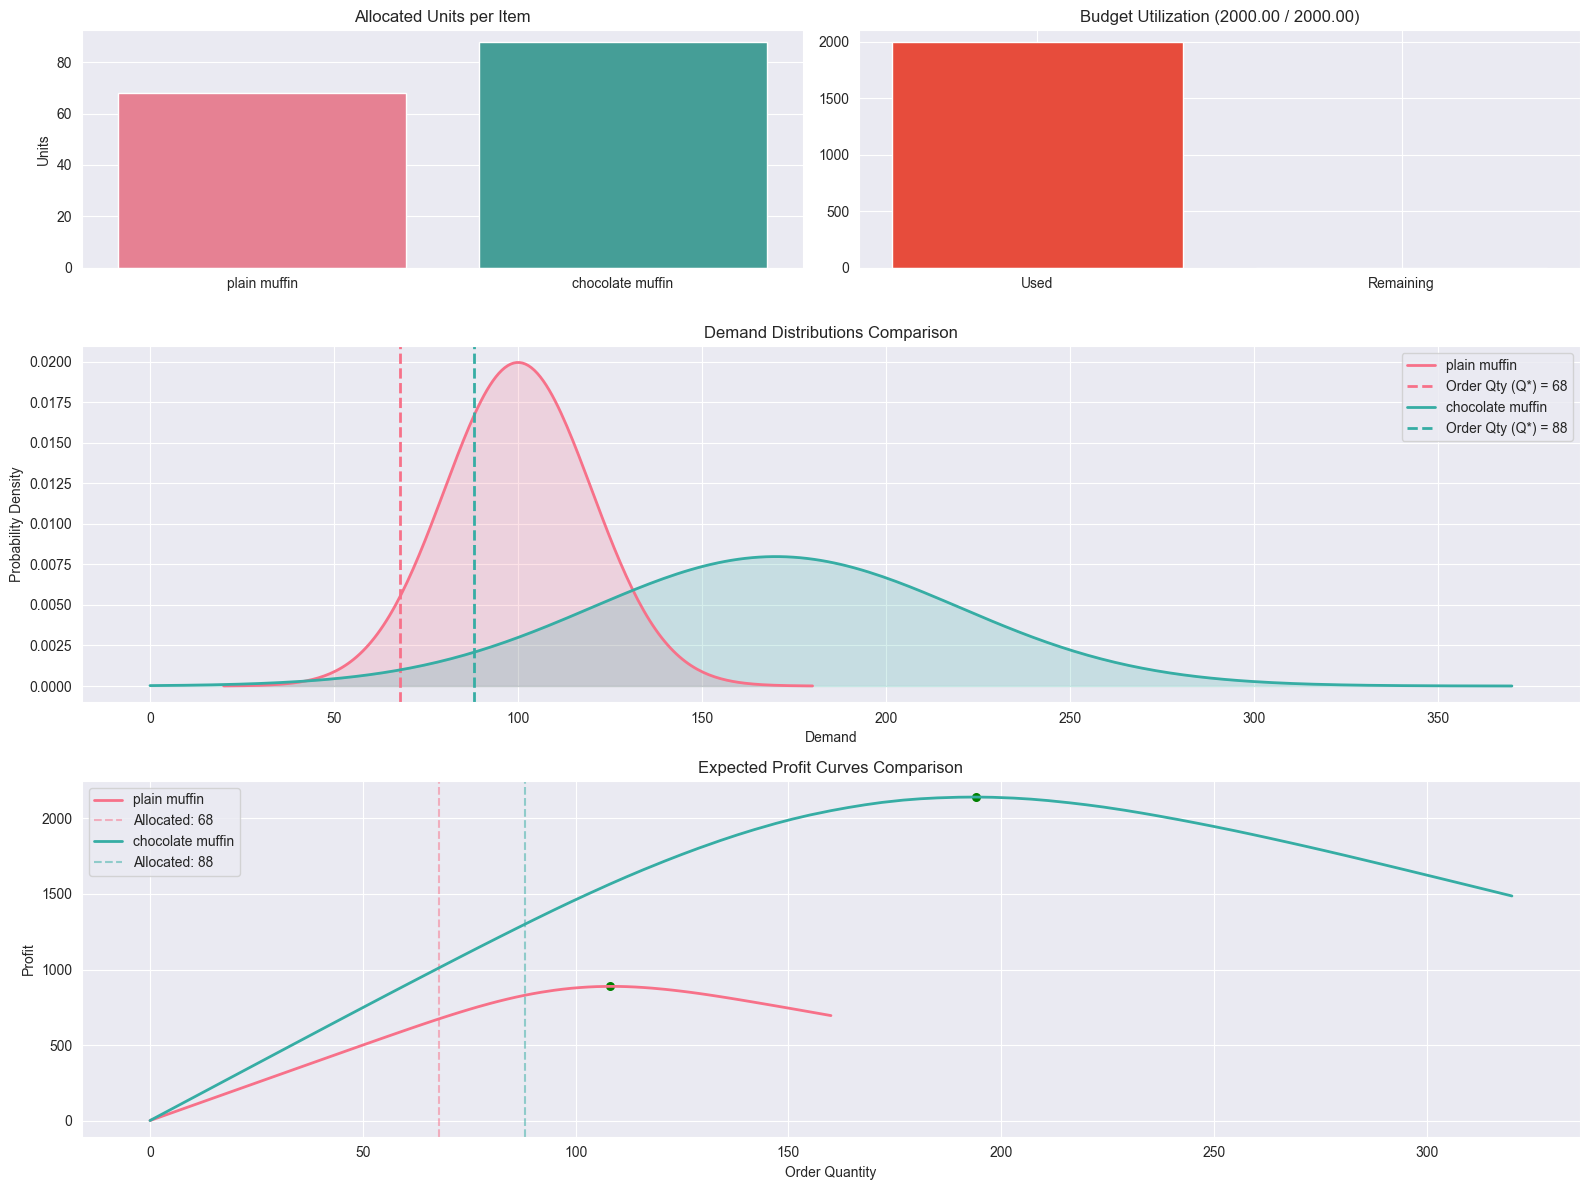

In [7]:
from inventory_management.items import Item
from inventory_management.distributions.demand_distributions import NormalDemand
from inventory_management.solvers import MultiItemConstrainedSolver
from inventory_management.plot_suite.portfolio import plot_multi_item_allocation


plain_muffin = Item("plain muffin", cost_price=10, selling_price=20, salvage_value=5)
chocolate_muffin = Item(
    "chocolate muffin", cost_price=15, selling_price=30, salvage_value=8
)

plain_demand = NormalDemand(100, 20)
chocolate_demand = NormalDemand(170, 50)

inventory_problems = problems = [
    (plain_muffin, plain_demand),
    (chocolate_muffin, chocolate_demand),
]

opt_allocation = MultiItemConstrainedSolver(inventory_problems, budget=2000).solve()
fig = plot_multi_item_allocation(opt_allocation, problems, budget=2000)

## Multiple constraints

If we have multiple constraints we can use a trust-region solver with the `scipy` library using the `ScipyOptimizationSolver`class. An advantage of this is we can get the lagrangian multipliers for the constraints.

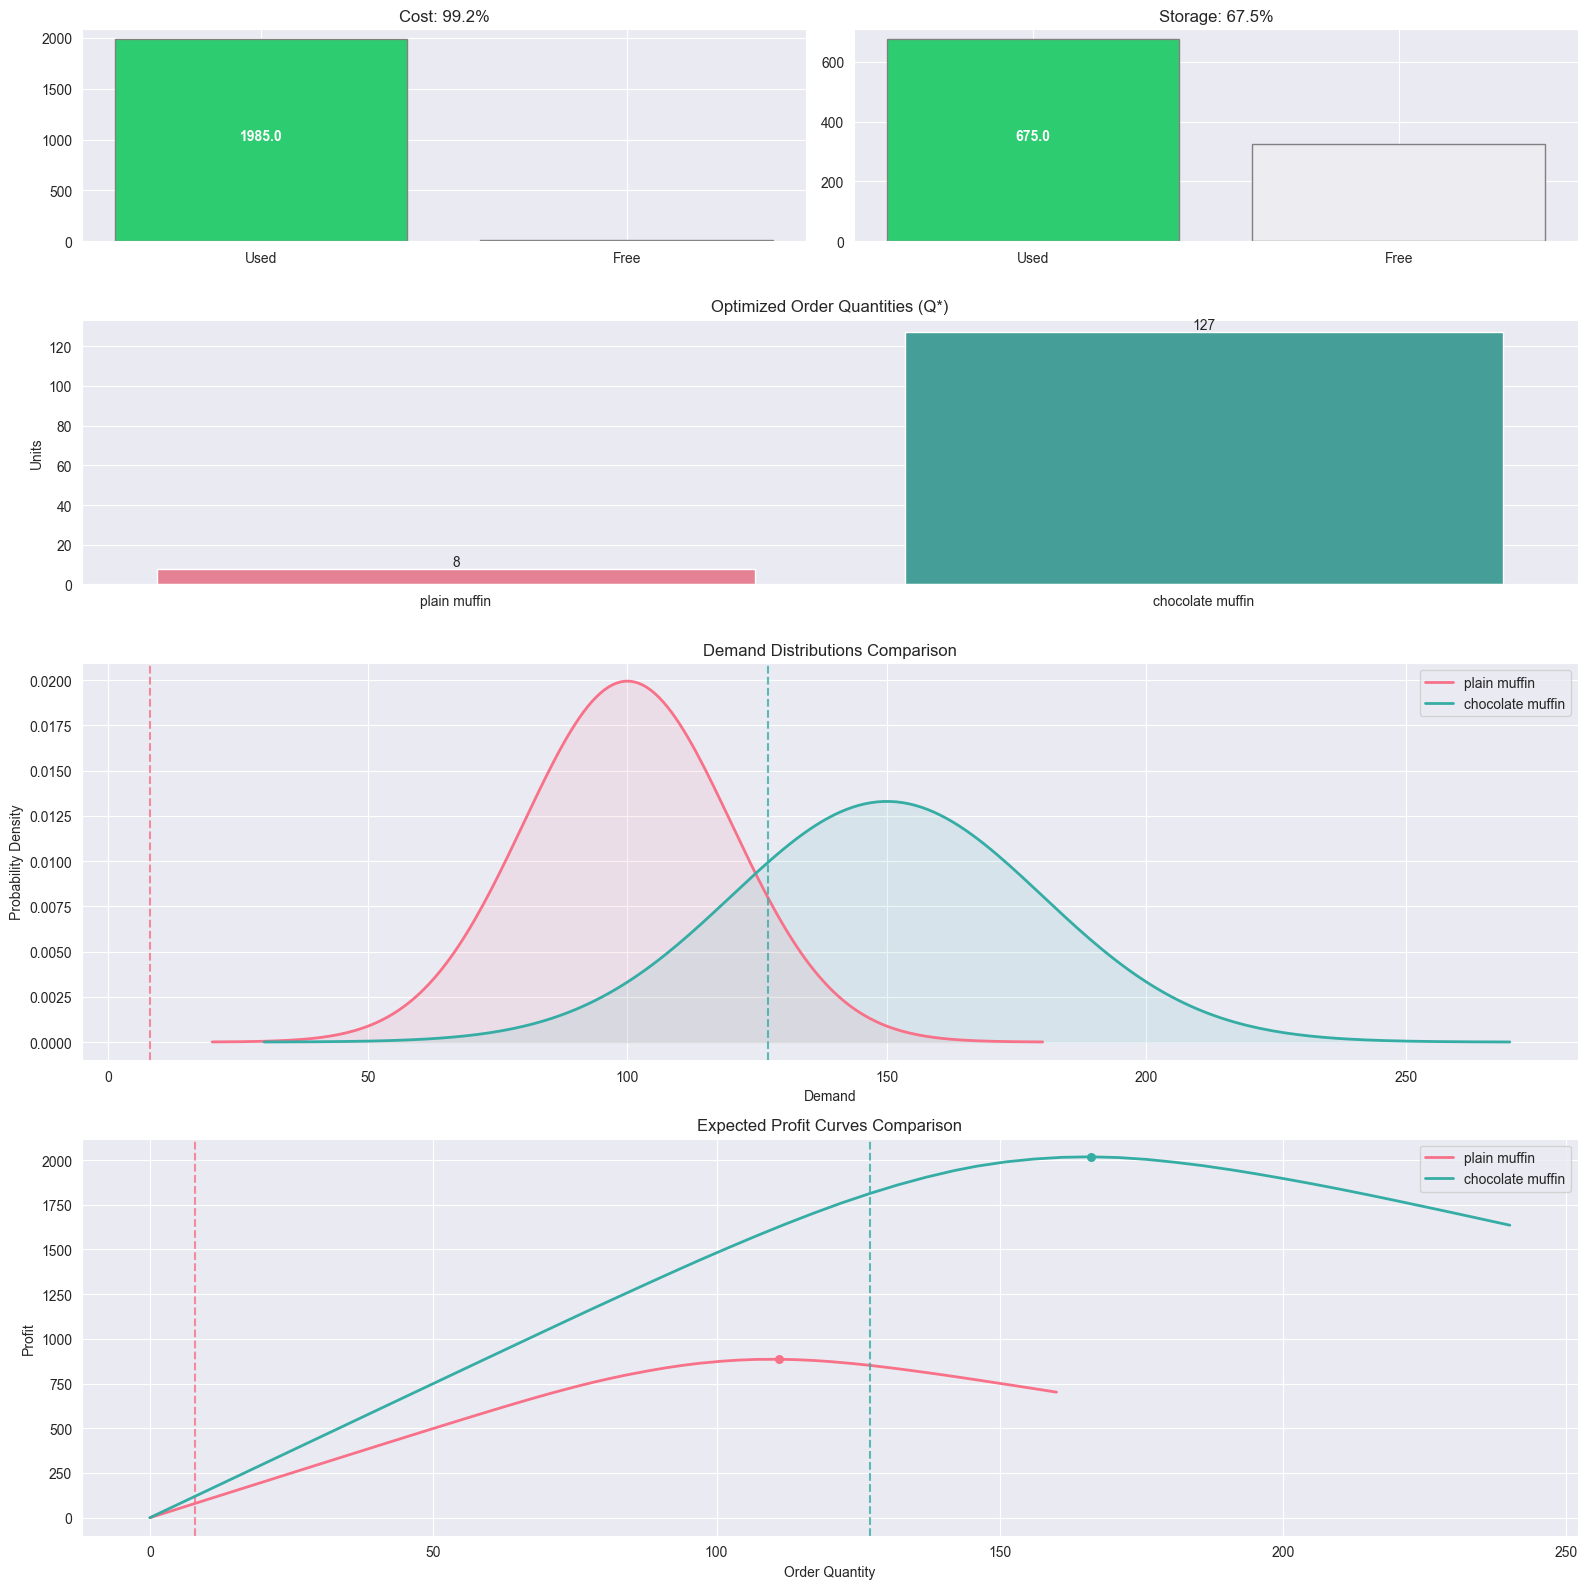

In [8]:
from inventory_management.solvers import ScipyOptimizationSolver
from inventory_management.plot_suite.portfolio import plot_constrained_allocation


plain_muffin = Item("plain muffin", cost_price=10, selling_price=20, salvage_value=5, constraints={"cost" : 10, "storage" : 5})
chocolate_muffin = Item(
    "chocolate muffin", cost_price=15, selling_price=30, salvage_value=8, constraints={"cost" : 15, "storage" : 5}
)

plain_demand = NormalDemand(100, 20)
chocolate_demand = NormalDemand(150, 30)

inventory_problems = problems = [
    (plain_muffin, plain_demand),
    (chocolate_muffin, chocolate_demand),
]

solver = ScipyOptimizationSolver(inventory_problems, limits = {"cost" : 2000, "storage" : 1000})
opt_allocation = solver.solve()
fig = plot_constrained_allocation(opt_allocation, problems, solver.limits)

We can then view the optimized result summary

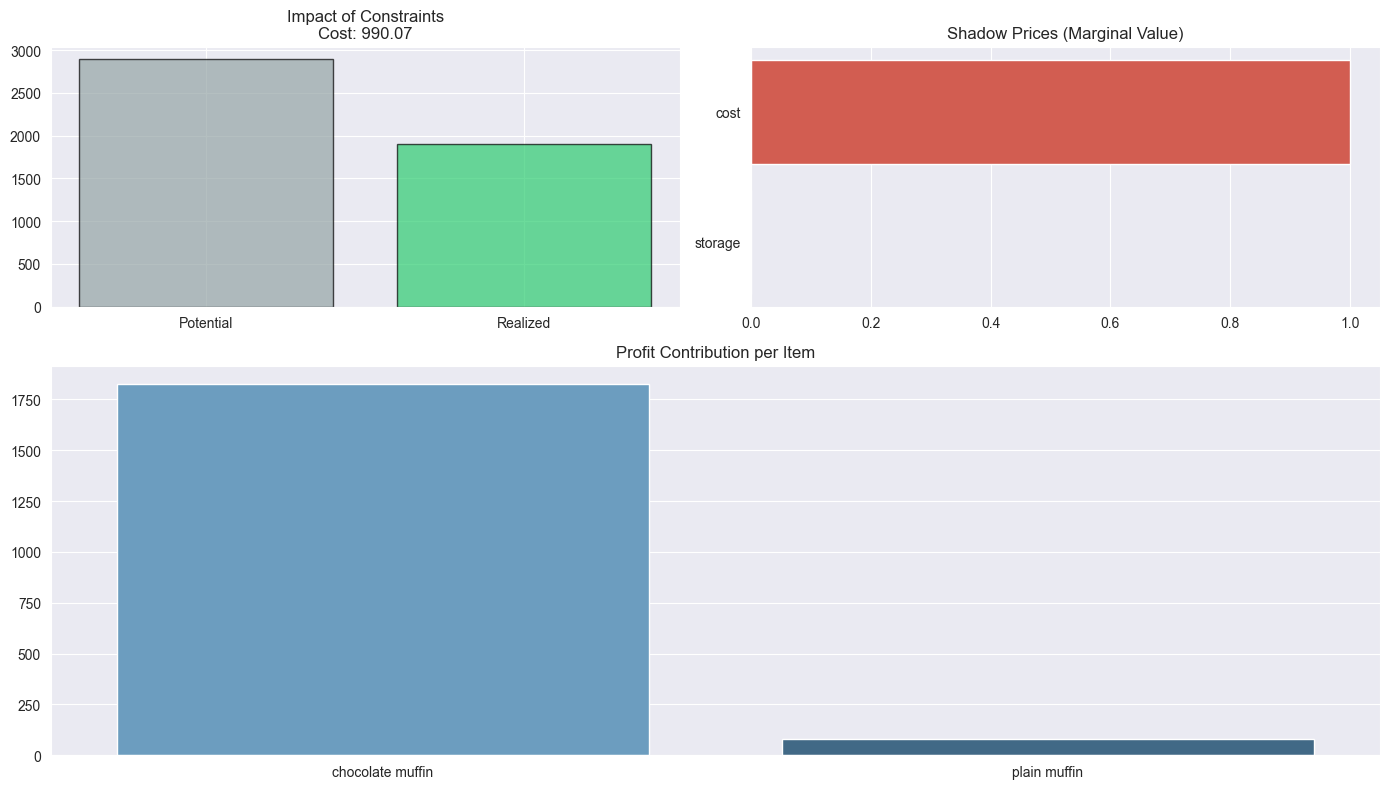

In [9]:
from inventory_management.plot_suite.portfolio import plot_optimization_summary
fig = plot_optimization_summary(opt_allocation, problems, solver.lambdas)

The plot shows us the cost of the constraints, as well as the which constraints are the most impactful.